In [ ]:
!pip install pandas seaborn matplotlib -q

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
df_titanic = sns.load_dataset("titanic")

# Check Dataset Info (Data types and nulls)
print("--- Dataset Info ---")
df_titanic.info()

# Summary Statistics (Math snapshot)
print("\n--- Summary Statistics ---")
display(df_titanic.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Summary Statistics ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df_titanic.to_csv("titanic.csv", index=False)

In [ ]:
# Check the sum of missing values before cleaning
print("--- Missing values before cleaning ---")
display(df_titanic.isnull().sum())

# Drop the 'deck' column
df_titanic.drop('deck', axis=1, inplace=True)

# Calculate the median age
median_age = df_titanic['age'].median()

# Fill missing 'age' values with the median age
df_titanic['age'].fillna(median_age, inplace=True)

# Check the sum of missing values after cleaning
print("\n--- Missing values after cleaning ---")
display(df_titanic.isnull().sum())

--- Missing values before cleaning ---


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0



--- Missing values after cleaning ---


/tmp/ipykernel_7191/244680763.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic['age'].fillna(median_age, inplace=True)


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


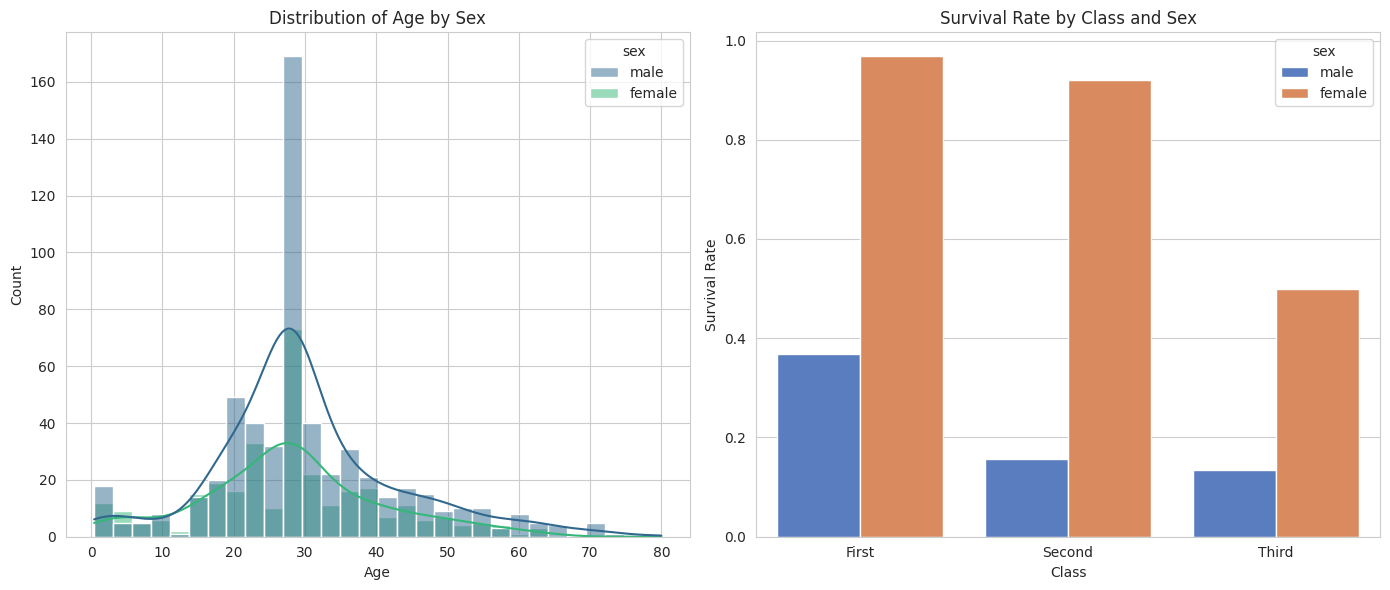

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Plot 1: Histplot for 'age' with kde=True and hue='sex'
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=df_titanic, x='age', kde=True, hue='sex', palette='viridis')
plt.title('Distribution of Age by Sex')
plt.xlabel('Age')
plt.ylabel('Count')

# Plot 2: Barplot with 'class' on x-axis, 'survived' on y-axis, and hue='sex'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(data=df_titanic, x='class', y='survived', hue='sex', palette='muted', errorbar=None)
plt.title('Survival Rate by Class and Sex')
plt.xlabel('Class')
plt.ylabel('Survival Rate')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
# Create 'family_size' column
df_titanic['family_size'] = df_titanic['sibsp'] + df_titanic['parch']

# One-Hot Encode the 'sex' column
df_titanic = pd.get_dummies(df_titanic, columns=['sex'], drop_first=True, dtype=int)

# Rename the new 'sex' column for clarity (e.g., 'sex_male' -> 'male')
df_titanic.rename(columns={'sex_male': 'male'}, inplace=True)

# Display the first few rows to show the changes
print("DataFrame after adding 'family_size' and One-Hot Encoding 'sex':")
display(df_titanic.head())

DataFrame after adding 'family_size' and One-Hot Encoding 'sex':


,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,male
0,0,3,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,1
1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1,0
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,0
3,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1,0
4,0,3,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0,1


In [ ]:
# Drop redundant columns created by Seaborn or text columns we can't use
columns_to_drop =[ 'alive', 'embark_town']
df_final = df_titanic.drop(columns=columns_to_drop)

print("Final Dataset ready for an ML Algorithm:")
df_final.info()

Final Dataset ready for an ML Algorithm:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  alone        891 non-null    bool    
 11  family_size  891 non-null    int64   
 12  male         891 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(6), object(2)
memory usage: 72.5+ KB


In [ ]:
# 1. Load the Iris dataset
df_iris = sns.load_dataset("iris")

# 2. Check for missing values (Step 2: Cleaning)
print("--- Missing Values ---")
print(df_iris.isnull().sum())

--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


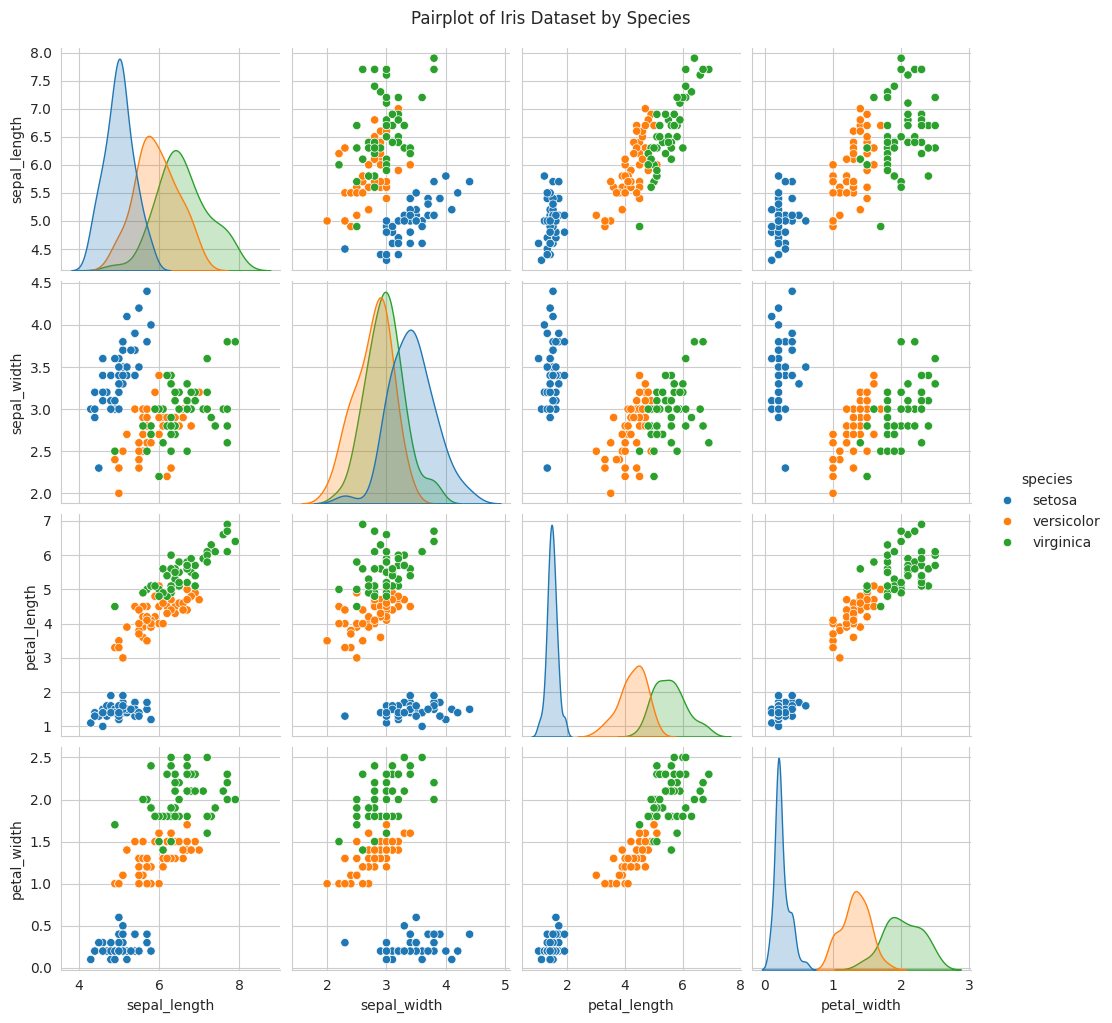

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot for the iris dataset, coloring points by 'species'
sns.pairplot(df_iris, hue='species')
plt.suptitle('Pairplot of Iris Dataset by Species', y=1.02) # Add a main title
plt.show()